# Notebook 2: Terrain Analysis

## Landslide Hazard Zonation Mapping – Idukki District, Kerala

### Objective

This notebook derives terrain-based conditioning factors from the clipped Digital Elevation Model (DEM) generated in Notebook 1.

The following terrain factors are generated:

- Slope
- Aspect
- Drainage Network
- Drainage Density

These datasets will be used in the weighted overlay model for landslide hazard zonation.

---

### Input

- Clipped DEM (`idukki_dem.tif`)

### Outputs

- Slope Raster
- Aspect Raster
- Drainage Network
- Drainage Density Raster
- Publication-quality Maps

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import os

import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.plot import show

from scipy import ndimage

# Plot settings
plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["font.size"] = 12

print("=" * 60)
print("Libraries imported successfully!")
print("=" * 60)

Libraries imported successfully!


In [3]:
import os

print(os.path.exists("/content/drive/MyDrive"))

False


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
# ============================================================
# Define Project Paths
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

INPUT_DEM = os.path.join(PROJECT_DIR, "outputs", "rasters", "idukki_dem.tif")

OUTPUT_RASTERS = os.path.join(PROJECT_DIR, "outputs", "rasters")
OUTPUT_FIGURES = os.path.join(PROJECT_DIR, "outputs", "figures")

os.makedirs(OUTPUT_RASTERS, exist_ok=True)
os.makedirs(OUTPUT_FIGURES, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Input DEM:", INPUT_DEM)

Project directory: /content/drive/MyDrive/Landslide-Hazard-Zonation
Input DEM: /content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/idukki_dem.tif


In [6]:
# ============================================================
# Load Clipped DEM
# ============================================================

import rasterio

with rasterio.open(INPUT_DEM) as src:
    dem = src.read(1)
    profile = src.profile
    transform = src.transform
    crs = src.crs
    resolution = transform.a

print("=" * 60)
print("DEM loaded successfully!")
print("=" * 60)

print(f"Shape      : {dem.shape}")
print(f"Resolution : {resolution:.8f} degrees")
print(f"CRS        : {crs}")

DEM loaded successfully!
Shape      : (3902, 2823)
Resolution : 0.00027778 degrees
CRS        : EPSG:4326


## Slope Calculation

### Objective

Slope represents the rate of elevation change and is one of the most influential factors controlling landslide occurrence.

Steeper slopes generally have higher susceptibility to slope failures due to increased gravitational forces.

In this section, slope is calculated from the clipped DEM using elevation gradients.

In [7]:
# ============================================================
# Calculate Slope
# ============================================================

# Calculate elevation gradients
dz_dy, dz_dx = np.gradient(dem)

# Compute slope in radians
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))

# Convert to degrees
slope = np.degrees(slope_rad)

print("=" * 60)
print("Slope calculated successfully!")
print("=" * 60)

print(f"Minimum Slope : {np.nanmin(slope):.2f}°")
print(f"Maximum Slope : {np.nanmax(slope):.2f}°")
print(f"Mean Slope    : {np.nanmean(slope):.2f}°")

Slope calculated successfully!
Minimum Slope : 0.00°
Maximum Slope : 90.00°
Mean Slope    : 33.45°


In [8]:
# ============================================================
# Save Slope Raster
# ============================================================

slope_profile = profile.copy()

slope_profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw"
)

SLOPE_PATH = os.path.join(OUTPUT_RASTERS, "slope.tif")

with rasterio.open(SLOPE_PATH, "w", **slope_profile) as dst:
    dst.write(slope.astype(rasterio.float32), 1)

print("Slope raster saved successfully!")
print(SLOPE_PATH)

Slope raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/slope.tif


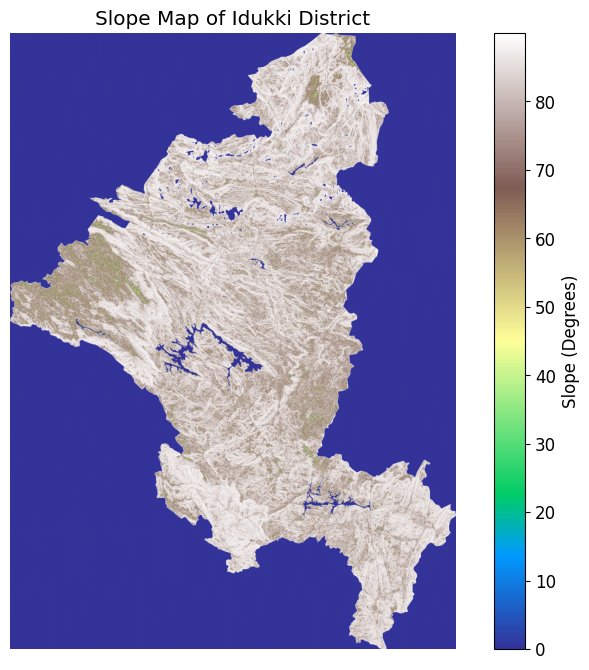

Slope map saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_slope_map.png


In [9]:
# ============================================================
# Plot Slope Map
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(slope, cmap="terrain")

plt.colorbar(label="Slope (Degrees)")

plt.title("Slope Map of Idukki District")

plt.axis("off")

SLOPE_FIG = os.path.join(OUTPUT_FIGURES, "idukki_slope_map.png")

plt.savefig(
    SLOPE_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Slope map saved successfully!")
print(SLOPE_FIG)

In [10]:
print("Minimum Slope :", np.nanmin(slope))
print("Maximum Slope :", np.nanmax(slope))
print("Mean Slope    :", np.nanmean(slope))

Minimum Slope : 0.0
Maximum Slope : 89.99850491872296
Mean Slope    : 33.453404966679386


## Aspect Calculation

### Objective

Aspect represents the compass direction that a slope faces. It influences solar radiation, soil moisture, vegetation growth, and weathering processes, making it an important conditioning factor in landslide susceptibility analysis.

The aspect raster is derived from the elevation gradients of the clipped DEM.

In [11]:
# ============================================================
# Calculate Aspect
# ============================================================

# Compute elevation gradients
dz_dy, dz_dx = np.gradient(dem)

# Calculate aspect in radians
aspect_rad = np.arctan2(-dz_dx, dz_dy)

# Convert to degrees
aspect = np.degrees(aspect_rad)

# Convert negative values to compass directions (0–360°)
aspect = np.where(aspect < 0, 90.0 - aspect, 450.0 - aspect)
aspect = aspect % 360

print("=" * 60)
print("Aspect calculated successfully!")
print("=" * 60)

print(f"Minimum Aspect : {np.nanmin(aspect):.2f}°")
print(f"Maximum Aspect : {np.nanmax(aspect):.2f}°")

Aspect calculated successfully!
Minimum Aspect : 0.00°
Maximum Aspect : 360.00°


In [12]:
# ============================================================
# Save Aspect Raster
# ============================================================

aspect_profile = profile.copy()

aspect_profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw"
)

ASPECT_PATH = os.path.join(OUTPUT_RASTERS, "aspect.tif")

with rasterio.open(ASPECT_PATH, "w", **aspect_profile) as dst:
    dst.write(aspect.astype(rasterio.float32), 1)

print("Aspect raster saved successfully!")
print(ASPECT_PATH)

Aspect raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/aspect.tif


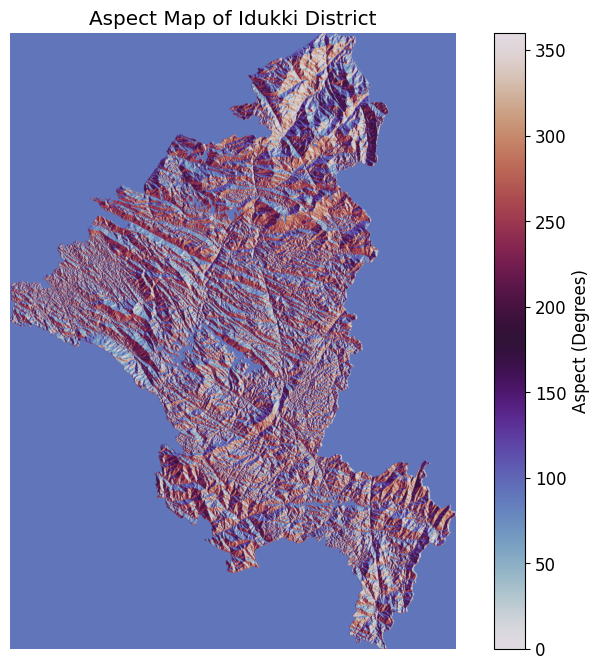

Aspect map saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_aspect_map.png


In [13]:
# ============================================================
# Plot Aspect Map
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(aspect, cmap="twilight")

plt.colorbar(label="Aspect (Degrees)")

plt.title("Aspect Map of Idukki District")

plt.axis("off")

ASPECT_FIG = os.path.join(
    OUTPUT_FIGURES,
    "idukki_aspect_map.png"
)

plt.savefig(
    ASPECT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Aspect map saved successfully!")
print(ASPECT_FIG)

# Terrain Analysis Summary

## Completed Analyses

This notebook successfully derived the primary terrain parameters required for landslide susceptibility analysis from the clipped DEM.

### Outputs Generated

- Slope Raster
- Aspect Raster
- Slope Map
- Aspect Map

These terrain derivatives will be used as input layers in the subsequent hydrological analysis and weighted overlay process.

In [14]:
# ============================================================
# NOTEBOOK 2 COMPLETED
# ============================================================

print("=" * 60)
print("NOTEBOOK 2 COMPLETED")
print("=" * 60)

print("\nOutputs generated:")

print("✓ slope.tif")
print("✓ aspect.tif")
print("✓ idukki_slope_map.png")
print("✓ idukki_aspect_map.png")

print("\nTerrain analysis completed successfully.")

NOTEBOOK 2 COMPLETED

Outputs generated:
✓ slope.tif
✓ aspect.tif
✓ idukki_slope_map.png
✓ idukki_aspect_map.png

Terrain analysis completed successfully.
